Overfitting occurs when a neural network memorizes the specific details, quirks, and noise of its training data rather than learning the broad, underlying patterns. This typically happens when a model is too complex for the task at hand, is trained for too long without intervention, or is fed data that is insufficient, unrepresentative, or full of errors. As a result, the network performs exceptionally well on the data it has already seen, but fails to make accurate predictions on new, unseen data because its internal logic is too rigidly tailored to the practice examples rather than the actual real-world problem.

In [78]:
#importing all therequired libraries:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense , Dropout

In [108]:
# Generate a concentric circle dataset
from sklearn.datasets import make_circles
X, y = make_circles(n_samples=500, noise=0.2, factor=0.5, random_state=42)

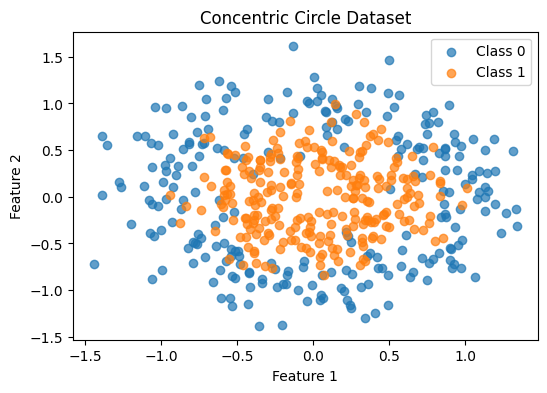

In [109]:
# Visualize the dataset
plt.figure(figsize=(6,4))
plt.scatter(X[y == 0, 0], X[y == 0, 1], label='Class 0', alpha=0.7)
plt.scatter(X[y == 1, 0], X[y == 1, 1], label='Class 1', alpha=0.7)
plt.title('Concentric Circle Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

In [110]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X,y,random_state=42)

In [82]:
#Training a normal neural network:
model = Sequential()
model.add(Dense(32, activation='relu', input_dim=2))
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [67]:
model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])

In [68]:
history = model.fit(x_train,y_train,epochs=500,validation_data=(x_test,y_test))

Epoch 1/500
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.4533 - loss: 0.7210 - val_accuracy: 0.3760 - val_loss: 0.7077
Epoch 2/500
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4533 - loss: 0.7053 - val_accuracy: 0.4240 - val_loss: 0.6974
Epoch 3/500
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4427 - loss: 0.6951 - val_accuracy: 0.4400 - val_loss: 0.6903
Epoch 4/500
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4427 - loss: 0.6872 - val_accuracy: 0.4400 - val_loss: 0.6835
Epoch 5/500
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5040 - loss: 0.6799 - val_accuracy: 0.5120 - val_loss: 0.6772
Epoch 6/500
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5520 - loss: 0.6726 - val_accuracy: 0.5680 - val_loss: 0.6702
Epoch 7/500
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5947 - loss: 0.6647 - val_accuracy: 0.6560 - val_loss: 0.6622
Epoch 8/500
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6693 - loss: 0.6561 - val_accuracy: 0.6960 - 

Text(0.5, 1.0, 'Model loss')

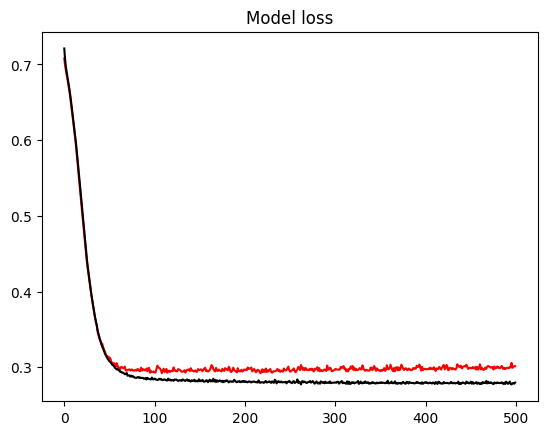

In [69]:
plt.plot(history.history['val_loss'],color= 'red')
plt.plot(history.history['loss'], color='black')
plt.title('Model loss')

Text(0.5, 1.0, 'Model accuracy')

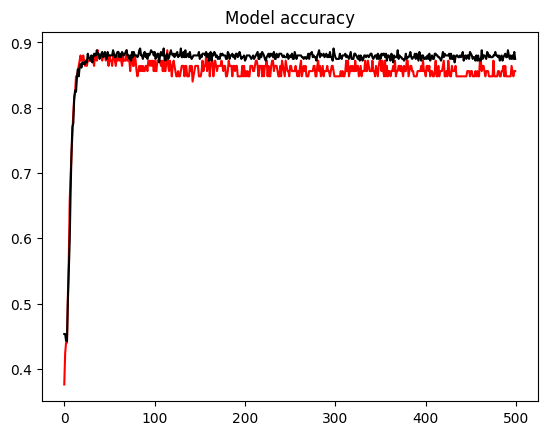

In [70]:
plt.plot(history.history['val_accuracy'],color='red')
plt.plot(history.history['accuracy'],color='black')
plt.title('Model accuracy')

Now trying to reduce the difference between val_lass and actual loss
1. Early stopping
2. Dropout Layers
3. Regularization

In [83]:
# 1. Early Stopping
from keras.callbacks import EarlyStopping
call_back = EarlyStopping(
    monitor='val_loss',
    patience=10,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=True)

In [84]:
model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])

In [85]:
history_cb = model.fit(x_train, y_train, epochs=500, validation_data=(x_test, y_test), callbacks=[call_back])

Epoch 1/500
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.4560 - loss: 0.6976 - val_accuracy: 0.4240 - val_loss: 0.6923
Epoch 2/500
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5227 - loss: 0.6858 - val_accuracy: 0.4400 - val_loss: 0.6853
Epoch 3/500
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4987 - loss: 0.6778 - val_accuracy: 0.4880 - val_loss: 0.6792
Epoch 4/500
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5120 - loss: 0.6709 - val_accuracy: 0.4960 - val_loss: 0.6726
Epoch 5/500
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5147 - loss: 0.6637 - val_accuracy: 0.5040 - val_loss: 0.6655
Epoch 6/500
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5280 - loss: 0.6558 - val_accuracy: 0.5520 - val_loss: 0.6581
Epoch 7/500
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5680 - loss: 0.6474 - val_accuracy: 0.6000 - val_loss: 0.6494
Epoch 8/500
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6160 - loss: 0.6382 - val_accuracy: 0.6240 - 

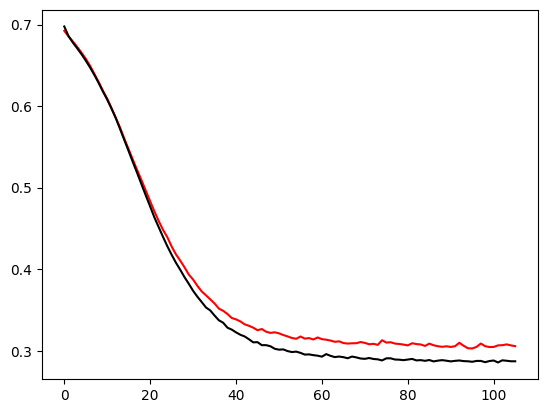

In [86]:
plt.plot(history_cb.history['val_loss'],color= 'red')
plt.plot(history_cb.history['loss'], color='black')

In [93]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 32)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,284 (5.02 KB)

 Trainable params: 641 (2.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 643 (2.52 KB)

In [97]:
model.get_weights()

[array([[ 0.3355267 , -0.55237836, -0.34868655,  0.3072241 ,  0.4781128 ,
         -0.50422484,  0.34213543,  0.09189518, -0.44674265,  0.04606844,
         -0.3048315 , -0.5585962 ,  0.04424805,  0.08127754, -0.43885884,
          0.04429376,  0.09860153, -0.3948791 ,  0.53308547,  0.33174708,
         -0.24025099,  0.14301005,  0.39333758, -0.06754175,  0.3114181 ,
          0.17033164,  0.05974242, -0.19303982,  0.36254352,  0.34180903,
         -0.17531864,  0.20462994],
        [-0.471391  ,  0.04642548, -0.5801967 ,  0.2885035 ,  0.4753524 ,
          0.21282963, -0.3306272 , -0.27835953, -0.11607677, -0.4330435 ,
         -0.3242392 ,  0.3192081 , -0.13047914,  0.06476974,  0.14310351,
          0.09796073,  0.42206976,  0.2251858 ,  0.36583006,  0.19122627,
         -0.6050693 , -0.4251486 ,  0.5757178 ,  0.3747158 , -0.24298112,
          0.390152  , -0.30794945, -0.5344666 , -0.06675367, -0.48875234,
          0.01065714,  0.2145411 ]], dtype=float32),
 array([-1.5727358e-01,

In [87]:
# 2. Dropout Layers
modelD = Sequential()
modelD.add(Dense(32, activation='relu', input_dim=2))
modelD.add(Dropout(0.5))
modelD.add(Dense(16, activation='relu'))
modelD.add(Dropout(0.4))
modelD.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [88]:
modelD.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])

In [89]:
histry_D = modelD.fit(x_train, y_train, epochs=400, validation_data=(x_test, y_test))

Epoch 1/400
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.4693 - loss: 0.6941 - val_accuracy: 0.4720 - val_loss: 0.6843
Epoch 2/400
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5173 - loss: 0.6760 - val_accuracy: 0.4960 - val_loss: 0.6803
Epoch 3/400
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5040 - loss: 0.6803 - val_accuracy: 0.5360 - val_loss: 0.6742
Epoch 4/400
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5253 - loss: 0.6709 - val_accuracy: 0.5440 - val_loss: 0.6701
Epoch 5/400
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5547 - loss: 0.6701 - val_accuracy: 0.5520 - val_loss: 0.6659
Epoch 6/400
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5173 - loss: 0.6656 - val_accuracy: 0.5680 - val_loss: 0.6609
Epoch 7/400
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5307 - loss: 0.6689 - val_accuracy: 0.5680 - val_loss: 0.6560
Epoch 8/400
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5307 - loss: 0.6577 - val_accuracy: 0.5760 

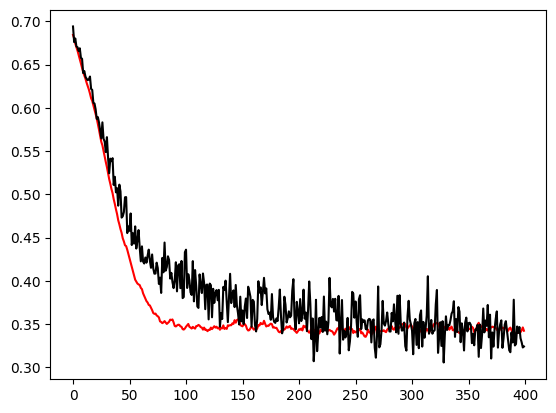

In [91]:
plt.plot(histry_D.history['val_loss'],color= 'red')
plt.plot(histry_D.history['loss'], color='black')

In [111]:
# 3. Regulariztion
modelR = Sequential()
l2 = tensorflow.keras.regularizers.l2(0.03)
modelR.add(Dense(32, activation='relu', input_dim=2,kernel_regularizer = l2))
modelR.add(Dense(16, activation='relu'))
modelR.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [112]:
modelR.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])

In [113]:
history_R = modelR.fit(x_train, y_train, epochs=400, validation_data=(x_test, y_test))

Epoch 1/400
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.5200 - loss: 0.7878 - val_accuracy: 0.5280 - val_loss: 0.7764
Epoch 2/400
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5333 - loss: 0.7680 - val_accuracy: 0.5440 - val_loss: 0.7621
Epoch 3/400
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5653 - loss: 0.7532 - val_accuracy: 0.5680 - val_loss: 0.7494
Epoch 4/400
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6000 - loss: 0.7391 - val_accuracy: 0.6000 - val_loss: 0.7364
Epoch 5/400
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6533 - loss: 0.7253 - val_accuracy: 0.6080 - val_loss: 0.7238
Epoch 6/400
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6320 - loss: 0.7126 - val_accuracy: 0.6800 - val_loss: 0.7115
Epoch 7/400
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6747 - loss: 0.7006 - val_accuracy: 0.6800 - val_loss: 0.7007
Epoch 8/400
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6960 - loss: 0.6887 - val_accuracy: 0.6960 - 

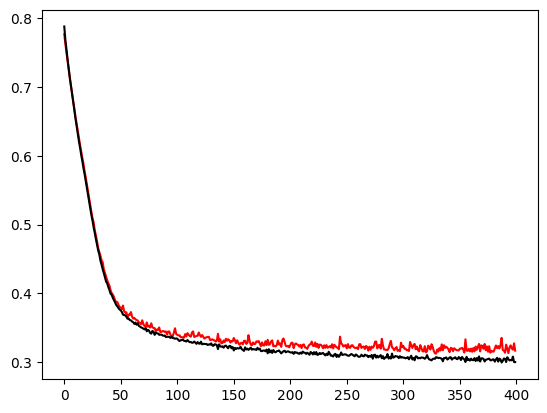

In [114]:
plt.plot(history_R.history['val_loss'],color='red')
plt.plot(history_R.history['loss'],color='black')